In [5]:
import pandas as pd

df = pd.read_csv("Telco_customer_churn.csv")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
df.shape
df.info()
df["Churn Label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
churn_rate = (1869 / 7043) * 100
print(round(churn_rate, 2))

26.54


In [11]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [12]:
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [13]:
pd.crosstab(df["Internet Service"], df["Churn Label"])

Churn Label,No,Yes
Internet Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [15]:
pd.crosstab(df["Payment Method"], df["Churn Label"])

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


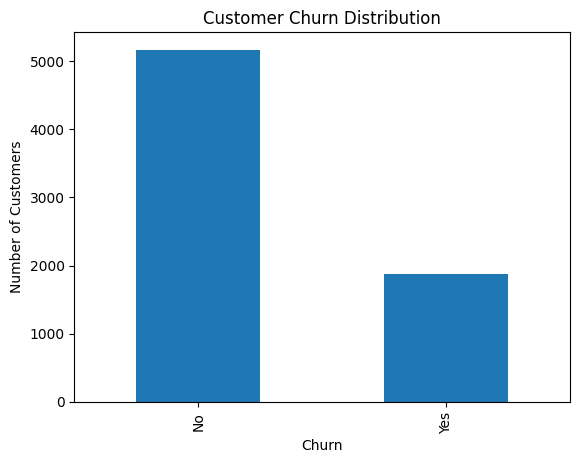

In [19]:
import matplotlib.pyplot as plt

df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

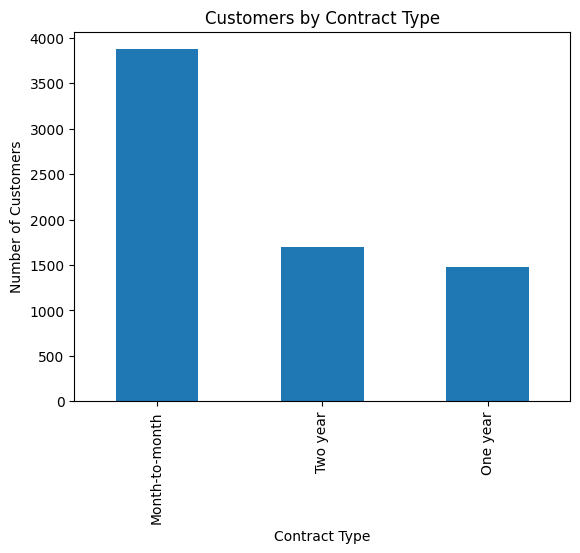

In [20]:
df["Contract"].value_counts().plot(kind="bar")

plt.title("Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

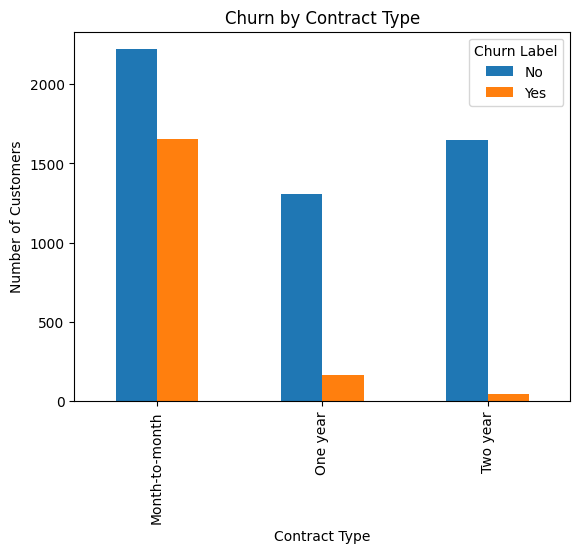

In [21]:
contract_churn = pd.crosstab(df["Contract"], df["Churn Label"])

contract_churn.plot(kind="bar")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

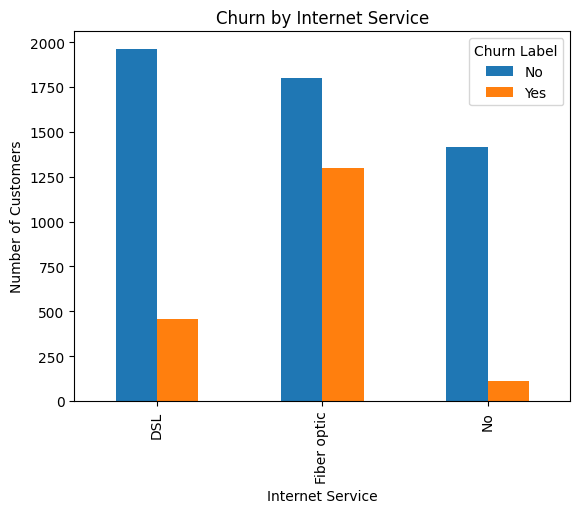

In [22]:
internet_churn = pd.crosstab(df["Internet Service"], df["Churn Label"])

internet_churn.plot(kind="bar")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

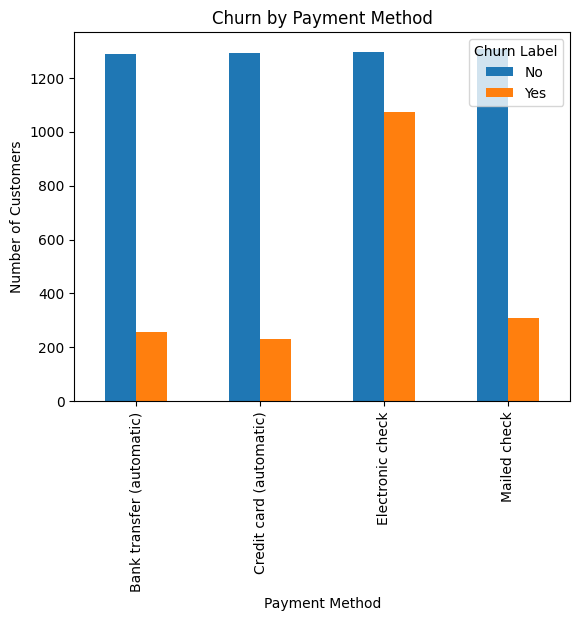

In [23]:
payment_churn = pd.crosstab(df["Payment Method"], df["Churn Label"])

payment_churn.plot(kind="bar")

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [25]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [26]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [27]:
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


In [28]:
df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

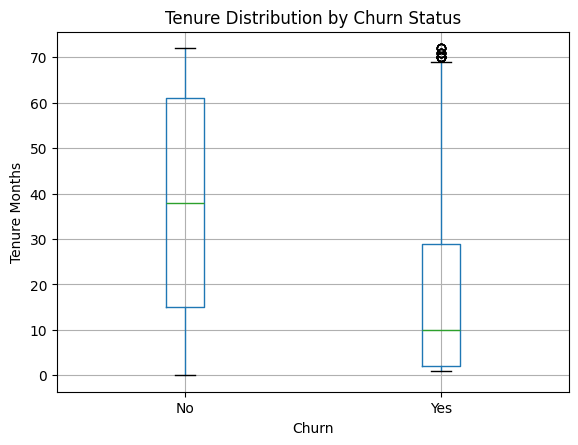

In [29]:
df.boxplot(column="Tenure Months", by="Churn Label")

plt.title("Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")

plt.show()

In [30]:
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

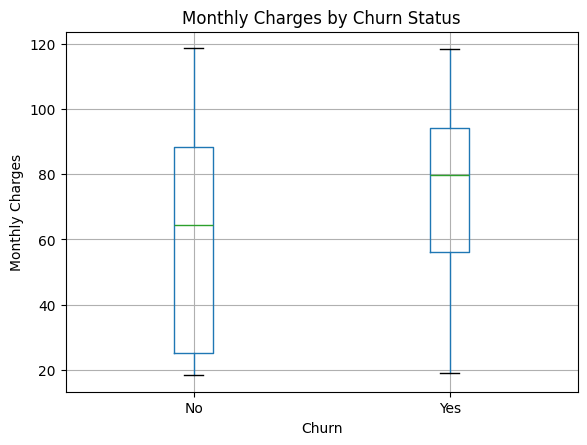

In [31]:
df.boxplot(column="Monthly Charges", by="Churn Label")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [33]:
df["Churn Reason"].value_counts().head(10)

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64

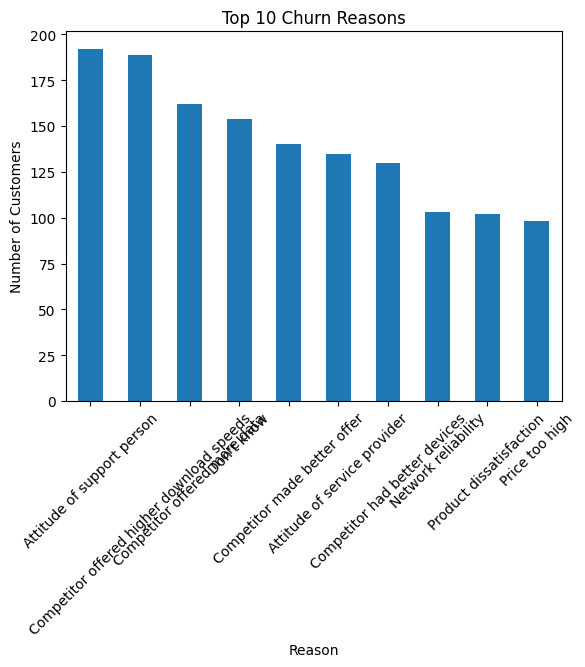

In [34]:
df["Churn Reason"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Churn Reasons")
plt.xlabel("Reason")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()